In [6]:
%load_ext autoreload
%autoreload 2
import param_tool as pt
import os 
import numpy as np
from rdkit.Chem.Draw import IPythonConsole
import sys
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, rdFMCS
from typing import Callable
import MDAnalysis as mda
import glob
import re
from espaloma_charge import charge

import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import display, clear_output

IPythonConsole.ipython_useSVG = True
IPythonConsole.molSize = (600, 400)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
!pwd

/home/_shared/_projects/2022_md_FRET_nv/param_R_CIT


# Протокол расчета парциальных зарядов для модифицированных аминокислот
На вход подаються .smi-файлы мономера и полимеров аминокислоты, где аминокислота входит в состав полимера в положениях N M C. 
У мономера должны бать группы COO<sup>-</sup> и N<sup>+</sup>H<sub>3</sub>. У полимеров соответствующие группы на С и N концах.  

## Пример загрузки и отображения молекулы 

In [21]:
K_smi = pt.read_file('moleculse/Lysine_3M.smiles')
# R_CIT_smi = pt.read_file('moleculse/R_CIT.smiles')
K_chem = pt.smi_to_chem(K_smi, make_N_root=False)
# R_CIT_chem = pt.smi_to_chem(R_CIT_smi, make_N_root=True)

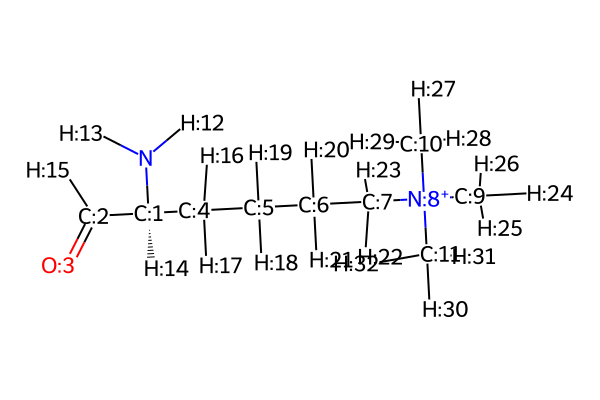

In [22]:
display(pt.draw_mol_with_atom_index(K_chem['Lysine_3M']))
# display(pt.draw_mol_with_atom_index(R_CIT_chem['R_CIT']))

## Шаг 0. Определение ключевых имен


In [7]:
PTM_name = 'Lysine_Cro'

In [8]:
os.makedirs(PTM_name, exist_ok=True)
os.makedirs(f'{PTM_name}/molecules/substructure',exist_ok=True)
os.makedirs(f'{PTM_name}/Acpype_data', exist_ok=True)

## Шаг 1 Открытие .smi-файлов 
Мы рекомендуем использовать словари для записи фаилов молекул, также можно передать путь к  `.smi` в виде строки или листа. На выход вы получите словарь с соответствующими ключами. 

In [9]:
monomer_smi = pt.read_file(f'{PTM_name}/molecules/Kcr_H.smiles')
# monomer_smi =mon_name.read_file('moleculse/R_CIT.smiles')
trimers_smi = pt.read_file([
                            f'{PTM_name}/molecules/GKcrG.smiles', 
                            # 'moleculse/GRG_CIT.smiles',
                            # 'moleculse/GR_CIT.smiles',

                           ],)
monomer_chem = pt.smi_to_chem(monomer_smi, make_N_root=False) # RDKit читает smi строку, переводит в chem и добавляет протоны
trimers_chem = pt.smi_to_chem(trimers_smi)
trimers_chem

{'GKcrG': <rdkit.Chem.rdchem.Mol at 0x7f8e4117beb0>}

In [10]:
# os.path.basename('moleculse/AKA_1M.smiles').split('.')[0]
mon_name = str(*monomer_smi.keys())
pol_name = str(*trimers_smi.keys())
print(mon_name, pol_name, sep='\n')

Kcr_H
GKcrG


## Шаг 2 Поиск подструктур мономера а.к. в полмерах
Наша задача выделить те атомы в составе полимеров, которые входят в состав мономера. Для этого функция `match_mon_to_pol` принимает на вход пару словарей с `Chem` фаилами. Словарь мономеров (один мономер) и полимеров (от 1 до ∞) соответственно. На выход подается словарь с ключами: `substructure`, `mon_pol_matches`, `N_match_atoms`, для кажого из полимеров. \
Где:
- `substructure` - сожердит общие подструктуры мономера и полимера, для каждого из полимеров в формате Chem .
- `mon_pol_matches` - содержит словари соответствия номеров атомов в общей подструктуре с номерами атомов в полимере молекула из общей подструктуры.
- `N_match_atoms` - количество общих атомов для мономера и полимера.\ 
(обычно вам не понадобится этот ключ, но он используется для подсвечивания общей структуры полимера на мономере)

Обратите внимание что набор атомов подструктур внутри мономера различается в зависимости от расположения а.к. в полимере

In [11]:
match_dict = pt.match_mon_to_pol(monomer_chem, trimers_chem, compare_any_bond = False)
# match_dict
print(match_dict.keys(),match_dict['substructure'], sep='\n')

dict_keys(['substructure', 'mon_pol_matches', 'N_match_atoms', 'mon_pol_atom_names'])
{'Kcr_H': <rdkit.Chem.rdchem.Mol object at 0x7f8e41140040>}


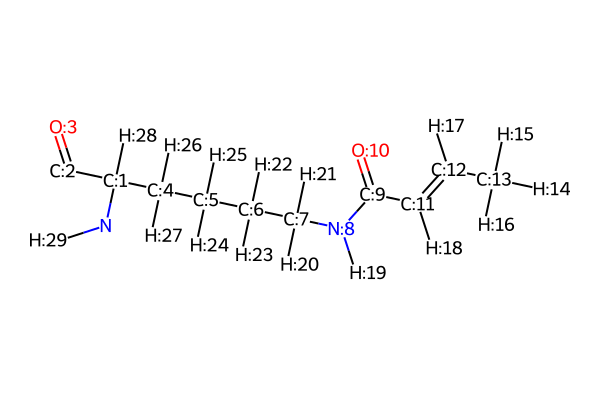

In [12]:
pt.draw_mol_with_atom_index(match_dict['substructure'][mon_name])

### Отрисовка полученных подструктур на молекулах мономера и полимера
Позволяет убедится в корректности структур

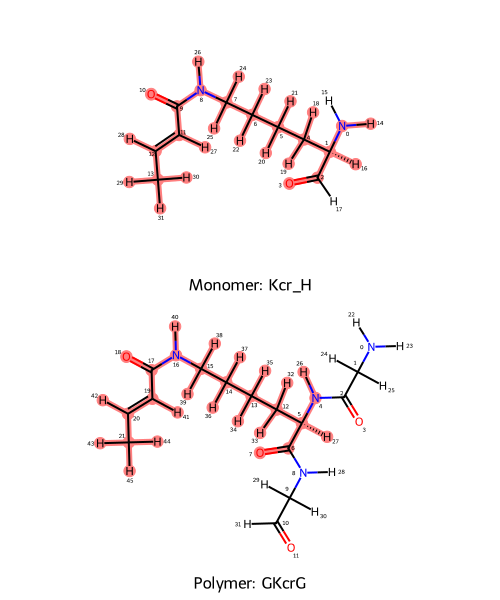

In [9]:
pt.draw_mon_pol_match(monomer_chem, trimers_chem, match_dict, add_small_atom_index=True, prefer_coord_gfen= False)

## Шаг 3 Сохранение молекул подструктур для N M С позиций 

Из молекулы мономера были выделены структуры аминокислот для каждой из позиций `N` `M` `C`. Важно ответить, что при созранение подструктур идет переупордочивание атомов таким образом, что первым атомом в молекуле становится автом **N** в составе аминогруппы. Далее имено они будут использоваться при получении файлов топологии. \
Ниже представленно несколько вариантов сохранения подструктур, но в итоге будут использоватсья файлы формата `.pdb` 

Были получены молекулярные формулы параметризируемых остатков `match_dict['substructure']`. Именно они будут использоваться для получения фаилов топологии в следующем ноутбуке.

#### Сохранение подструктур в виде **smiles**

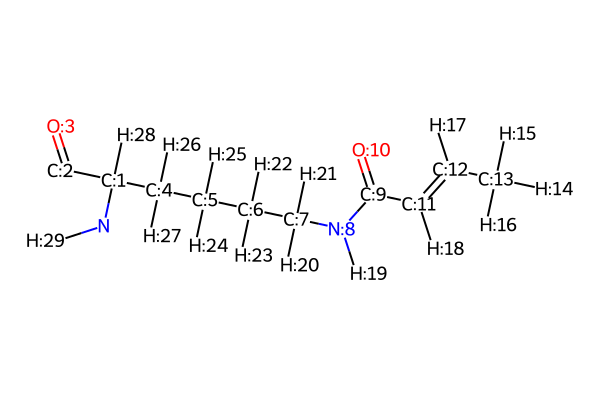

In [12]:
pt.draw_mol_with_atom_index(match_dict['substructure'][mon_name])

In [13]:
for chem_name, chem_mol in  match_dict['substructure'].items():
    print(chem_name, chem_mol)
    pt.save_aa_chem_to_smiles(chem_mol, f'{PTM_name}/molecules/substructure/{chem_name}', canonical=False ,make_N_root=False)

Kcr_H <rdkit.Chem.rdchem.Mol object at 0x7f2379a16970>
Kcr_H.smiles saved to Lysine_Cro/molecules/substructure


##### Проверка сохраненных подструктур

In [14]:
test_smi = pt.read_file([f'{PTM_name}/molecules/substructure/{mon_name}.smiles',
                        ])
test_chem = pt.smi_to_chem(test_smi, addH=False, sanitize=False)
IPythonConsole.drawOptions.addAtomIndices = False

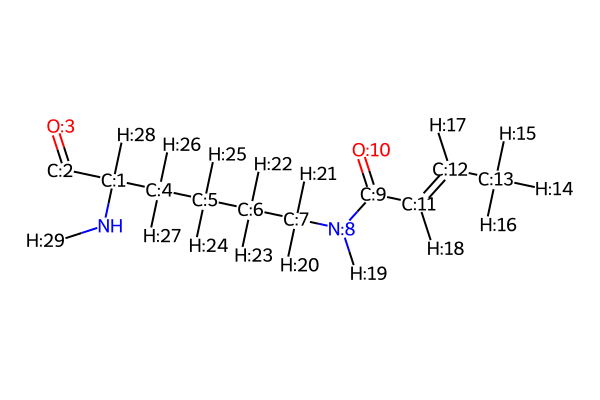

In [15]:
pt.draw_mol_with_atom_index(test_chem[mon_name])

### Сохранение подструктур в виде mol

In [30]:
list_N = []
for sub in match_dict['substructure'].values():
    N_index = pt.find_amino_nitrogen(sub)
    list_N.append(N_index)
print(list_N)
sub_name = ['NR_CIT', 'R_CIT', 'CR_CIT']
for chem_name, chem_mol, root in zip(sub_name, match_dict['substructure'].values(), list_N):
    pt.save_chem_to_mol(chem_mol, f'moleculse/substructure/{chem_name}', rootedAtAtom = root)
    print(chem_name, chem_mol)

10
10
11
[10, 10, 11]
NR_CIT <rdkit.Chem.rdchem.Mol object at 0x7f944627bee0>
R_CIT <rdkit.Chem.rdchem.Mol object at 0x7f944627bf40>
CR_CIT <rdkit.Chem.rdchem.Mol object at 0x7f9480340400>


In [53]:
mol_test = Chem.MolFromMolFile('moleculse/substructure/NR_CIT.mol', sanitize=False,removeHs=False)
# Chem.AddHs(mol_test)

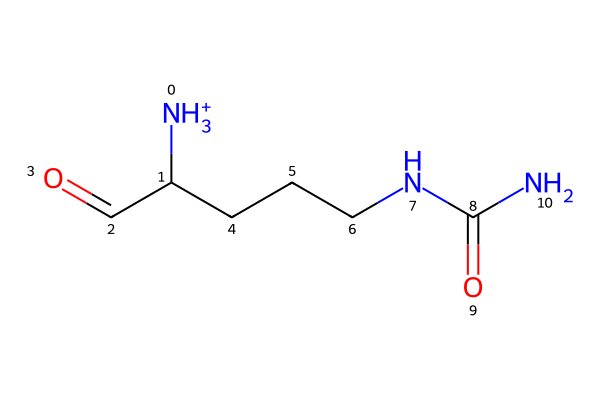

In [54]:
mol_test

In [41]:
IPythonConsole.drawOptions.addAtomIndices = True
mol_test

In [21]:
!pwd

/home/_shared/_projects/2022_md_FRET_nv/param_R_CIT


### Сохранение подструктур в виде **pdb**

То как выглядит подструктура для одного из вариантов позиционирования остатка в цепи:

/home/n_kristovsky/.conda/envs/topmol2/lib/python3.8/site-packages/psiresp/charge.py:282: FutureWarning: `symmetric_atoms_are_equivalent` will be set to False by default for now, as it is a new feature. It will be set to True by default in the future
  warnings.warn(


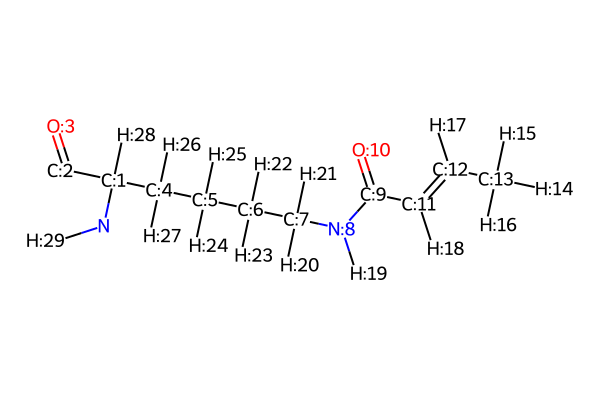

In [42]:
pt.draw_mol_with_atom_index(match_dict['substructure'][mon_name])

Сохранение подструктуры (т.е. атомов входящих в состав модифицированного остатка в зависимости от его позиции в полимере) в формате 
`pdb`. \
Далее полученные ДНК используются для получения парциальных зарядов и для получения файлов топологии. \
Кроме этого вы можете взять их и использовать в молекулярном  моделировании для добавления модифицированного остатка в вашу структуру.   

##### Одиночное сохранение:
Мы сохраняем остаток ак в составе которго атомы только входящие в этот остаток. \
Все имен аатомов уникальные

In [70]:
pt.save_aa_chem_to_pdb(match_dict[f'substructure'][mon_name], 
                       f'{PTM_name}/molecules/substructure/{mon_name}', 
                       resname = 'Kcr', 
                       resid= 2,
                       segid= 'A',
                       make_N_root=False)

Kcr_H.pdb saved to Lysine_Cro/molecules/substructure
Kcr_no_H.pdb saved to Lysine_Cro/molecules/substructure


[16:17:01] Molecule does not have explicit Hs. Consider calling AddHs()
[16:17:01] Molecule does not have explicit Hs. Consider calling AddHs()


##### Множественное сохранение:

In [10]:
sub_name = ['NR_CIT_1', 'R_CIT_1', 'CR_CIT_1']
resname_l = ['NRC', 'RC', 'CRC']
for chem_name, chem_mol, resname in zip(sub_name, match_dict['substructure'].values(), resname_l):
    pt.save_aa_chem_to_pdb(chem_mol, f'moleculse/substructure/{chem_name}_rdkit', resname = resname, make_N_root=True)

atom number: 0 became the root atom: 0
Длина atom_names_list не совпадает с количеством атомов в rdkit_mol. Будут использованы стандартные имена атомов.
NR_CIT_1_rdkit.pdb saved to moleculse/substructure


[13:16:38] Molecule does not have explicit Hs. Consider calling AddHs()
[13:16:38] Molecule does not have explicit Hs. Consider calling AddHs()


#### Проверка сохраненных молекул

In [71]:
# test_pdb = pt.pdb_to_chem(f'Lysine_Cro/molecules/substructure/Kcr_H2.pdb',
mon_name_no_H = mon_name.replace('_H','_no_H')
test_pdb = pt.pdb_to_chem([f'{PTM_name}/molecules/substructure/{mon_name}.pdb',
              f'{PTM_name}/molecules/substructure/{mon_name_no_H}.pdb',
              # 'moleculse/substructure/CR_CIT.pdb'
                          ])
test_pdb

{'Kcr_H': <rdkit.Chem.rdchem.Mol at 0x7fb1947b7d60>,
 'Kcr_no_H': <rdkit.Chem.rdchem.Mol at 0x7fb1947b7f20>}

Если все получилось, то вы молжны получить картинку тогоже остатка с такимиже типами связей и количеством атомов. \
В случае если вы использовали `make_N_root=True` последовательность нумерации атомов должна была поменяться и нулевым атомом должен был стать `N` в аминогруппе

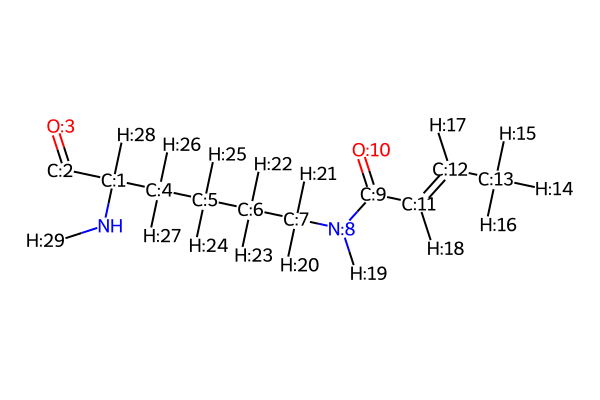

In [72]:
pt.draw_mol_with_atom_index(test_pdb[mon_name])

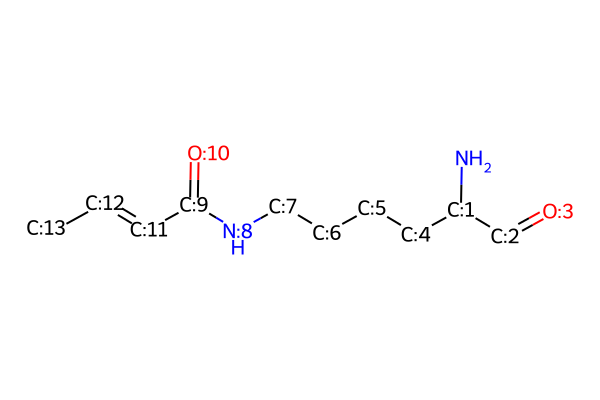

In [73]:
pt.draw_mol_with_atom_index(test_pdb[mon_name_no_H])

##### NGLview отрисовка

Поскольку мы сохранили pdb фаил то можно и через MDAnalysis и nglview посмотреть на него

In [20]:
nv.show_mdanalysis(mda.Universe(f'{PTM_name}/molecules/substructure/{mon_name}.pdb'))

NGLWidget()

## Шаг 4 Переименовка атомов в составе остатка с присвоением канонических имен к каноничным атомам  

Полученные на шаге 3 были полученые структуры остатков. Данные структуры имеют как канонические атомы (т.е. входят в состав каноничных аминокислоты), так и не канонические -- новые. \
На шаге 4 мы находим соствае парметризуемого остатка канонические атомы, которыек сохранилди ориганльные валентности и присваиваем им канонические имена атомов.

In [74]:
PTM_name = 'Lysine_Cro'
mon_name = 'Kcr_H'

# print(mon_name, pol_name, sep='\n')

### Сопоставление модифицированного остатка с референсными остатками

In [75]:
path_to_mod_aa = f'{PTM_name}/molecules/substructure/{mon_name}.pdb'

mod_aa_name = os.path.basename(path_to_mod_aa).split('.')[0]
print(mod_aa_name)
mod_aa_chem_dict = pt.pdb_to_chem(path_to_mod_aa)

ref_aa_chem_dict, match_data_dict, name_ref_triplet = pt.find_ref_aa(mod_aa_chem_dict, match_residue_number = 2, 
                                                                     main_match_data=True, type_match_dict= 'Names')   

Kcr_H
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Matched only with residue namber 2
Reference amino acid is Lys, with 18 matched atoms.


In [76]:
match_data_dict

{'substructure': {'GKG_H': <rdkit.Chem.rdchem.Mol at 0x7fb19450a7b0>},
 'N_match_atoms': {'GKG_H': 18},
 'mon_pol_matches': {'GKG_H': {29: 10,
   0: 9,
   1: 11,
   28: 12,
   4: 13,
   26: 14,
   27: 15,
   5: 16,
   24: 17,
   25: 18,
   6: 19,
   22: 20,
   23: 21,
   7: 22,
   20: 23,
   21: 24,
   2: 29,
   3: 30}},
 'mon_pol_atom_names': {'GKG_H': {'H': 'H',
   'N': 'N',
   'CA': 'CA',
   'HA': 'HA',
   'CB': 'CB',
   'HB2': 'HB1',
   'HB1': 'HB2',
   'CG': 'CG',
   'HG2': 'HG1',
   'HG1': 'HG2',
   'CD': 'CD',
   'HD2': 'HD1',
   'HD1': 'HD2',
   'CE': 'CE',
   'HE2': 'HE1',
   'HE1': 'HE2',
   'C': 'C',
   'O': 'O'}}}

['H',
 'N',
 'CA',
 'HA',
 'CB',
 'HB2',
 'HB1',
 'CG',
 'HG2',
 'HG1',
 'CD',
 'HD2',
 'HD1',
 'CE',
 'HE2',
 'HE1',
 'C',
 'O']

In [101]:
save_charges_json('general_atoms', list(*match_data_dict['mon_pol_atom_names'].values()), 'Lysine_Cro/')

Файл успешно сохранен: 
/home/_shared/_projects/2022_md_FRET_nv/param_R_CIT/Lysine_Cro/general_atoms.json


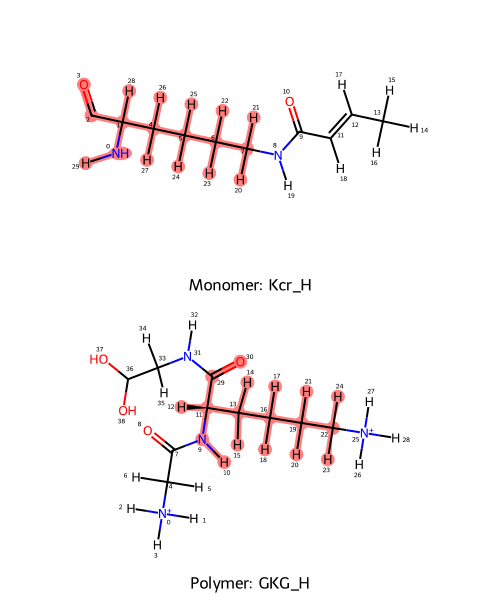

In [77]:
pt.draw_mon_pol_match(mod_aa_chem_dict, ref_aa_chem_dict, match_data_dict, 
                      add_small_atom_index=True, prefer_coord_gfen = False)

### Переименовка атомов в модифицированном остатке

In [79]:
key_map = next(iter(match_data_dict['mon_pol_matches'].keys()))
match_data_dict['mon_pol_matches'][key_map]

{29: 10,
 0: 9,
 1: 11,
 28: 12,
 4: 13,
 26: 14,
 27: 15,
 5: 16,
 24: 17,
 25: 18,
 6: 19,
 22: 20,
 23: 21,
 7: 22,
 20: 23,
 21: 24,
 2: 29,
 3: 30}

In [80]:
modifie_residue = pt.add_names_from_residue(mod_aa_chem_dict,
                       match_data_dict,
                        resid = 2,
                        resname='KCR',)

Counter({'N': 1, 'CA': 1, 'C': 1, 'O': 1, 'CB': 1, 'CG': 1, 'CD': 1, 'CE': 1, 'NZ': 1, 'CH': 1, 'OT2': 1, 'CT1': 1, 'CI': 1, 'CK': 1, 'HK3': 1, 'HK2': 1, 'HK1': 1, 'HI': 1, 'HT1': 1, 'HZ': 1, 'HE2': 1, 'HE1': 1, 'HD2': 1, 'HD1': 1, 'HG2': 1, 'HG1': 1, 'HB2': 1, 'HB1': 1, 'HA': 1, 'H': 1})
Дубликаты имен атомов не найдены.


In [81]:
save_molecule_as_pdb(modifie_residue, f'{PTM_name}/molecules/substructure/{PTM_name}_rn.pdb', format_coord='3D')

Молекула успешно сохранена в файле Lysine_Cro/molecules/substructure/Lysine_Cro_rn_3D.pdb в формате 3D.


[16:22:15] Molecule does not have explicit Hs. Consider calling AddHs()
[16:22:15] Molecule does not have explicit Hs. Consider calling AddHs()


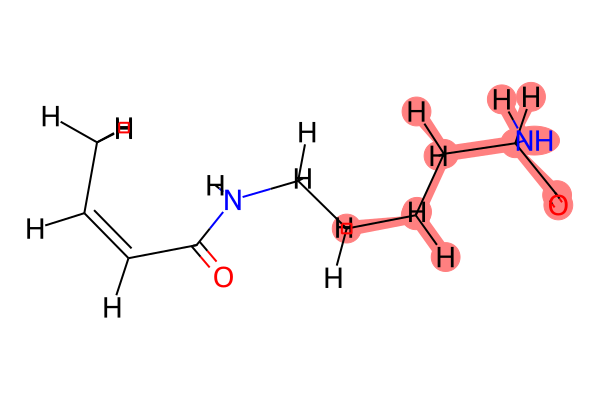

In [82]:
modifie_residue

### Шаг 4.1. Протонирование атомов, потерявших стандартную валентность 

Этот шаг необходим для дальнейшего получения файла itp для нашей а.к. \
Дело в том, что acpype отказывается создавать топологию для атомов с нестандартными валентностями, что вполне логично. Поэтому мы добавляем протоны, которых на самом деле нет в остатке. После в процесе редактирвоания itp мы удалим все строки с лишними протонами. \
Стоит отметить, что этот шаг можно также выполнить с использованием любого удобного вам молекулярного редактора (ChimeraX, PyMOL) взяв за основу pdb фаийл сохраненный на 3-ем шаге.

In [88]:
# Создание карты индексов атомов и их номеров

def add_protons_and_renumber_H(modifie_residue, resname='MOD', resid=1, segid='A'):
    atom_map = {atom.GetIdx(): atom.GetProp('AtomName') for atom in modifie_residue.GetAtoms()}
    names = list(atom_map.values())
    # print(atom_map)

    # Добавление протонов
    H_modifie_residue = Chem.AddHs(modifie_residue, addCoords=True)
    AllChem.Compute2DCoords(H_modifie_residue)
    
    # Назначение уникальных имен для новых атомам водорода
    for atom in H_modifie_residue.GetAtoms():
        if atom.GetPDBResidueInfo() is None:
            info = atom.GetPDBResidueInfo()
            print(info, atom.GetIdx(), atom.GetAtomMapNum())
            
            new_name = 'HW'
            while new_name in names:
                new_name = increment_name(new_name)
            names.append(new_name)

            set_PDB_residue_info(atom, new_name, resname, resid, segid)
            atom.SetProp('AtomName', new_name)
            atom.SetAtomMapNum(atom.GetIdx())
            # atom.SetI() = int(atom.GetAtomMapNum())
        
    order = [atom.GetIdx() for atom in H_modifie_residue.GetAtoms()]
    Chem.rdmolops.RenumberAtoms(H_modifie_residue, order)
    
    return H_modifie_residue

H_modifie_residue = add_protons_and_renumber_H(modifie_residue, resname='KCR', resid=2, segid='A')

None 30 0
None 31 0


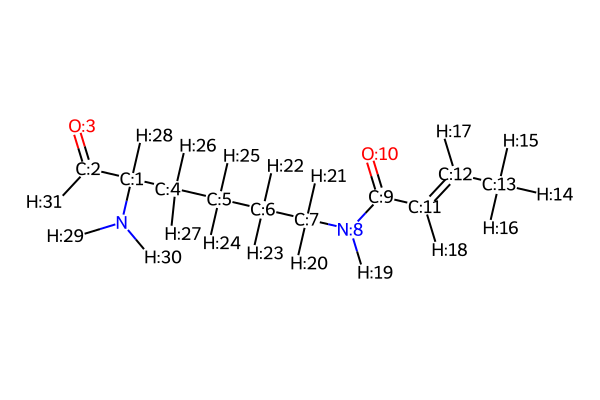

In [89]:
pt.draw_mol_with_atom_index(H_modifie_residue)

In [90]:
for atom in H_modifie_residue.GetAtoms():
    info = atom.GetPDBResidueInfo()
    print(info,info.GetResidueNumber(), info.GetResidueName(), atom.GetProp('AtomName'), atom.GetIdx(), atom.GetAtomMapNum())

<rdkit.Chem.rdchem.AtomPDBResidueInfo object at 0x7fb19444c2e0> 2 KCR N 0 0
<rdkit.Chem.rdchem.AtomPDBResidueInfo object at 0x7fb1945b1eb0> 2 KCR CA 1 1
<rdkit.Chem.rdchem.AtomPDBResidueInfo object at 0x7fb19444c660> 2 KCR C 2 2
<rdkit.Chem.rdchem.AtomPDBResidueInfo object at 0x7fb19444c040> 2 KCR O 3 3
<rdkit.Chem.rdchem.AtomPDBResidueInfo object at 0x7fb19444c3c0> 2 KCR CB 4 4
<rdkit.Chem.rdchem.AtomPDBResidueInfo object at 0x7fb19444c430> 2 KCR CG 5 5
<rdkit.Chem.rdchem.AtomPDBResidueInfo object at 0x7fb19444c4a0> 2 KCR CD 6 6
<rdkit.Chem.rdchem.AtomPDBResidueInfo object at 0x7fb19444c510> 2 KCR CE 7 7
<rdkit.Chem.rdchem.AtomPDBResidueInfo object at 0x7fb19444c580> 2 KCR NZ 8 8
<rdkit.Chem.rdchem.AtomPDBResidueInfo object at 0x7fb19444c5f0> 2 KCR CH 9 9
<rdkit.Chem.rdchem.AtomPDBResidueInfo object at 0x7fb19444c0b0> 2 KCR OT2 10 10
<rdkit.Chem.rdchem.AtomPDBResidueInfo object at 0x7fb19444c6d0> 2 KCR CT1 11 11
<rdkit.Chem.rdchem.AtomPDBResidueInfo object at 0x7fb19444c740> 2 KCR CI 

In [91]:

save_molecule_as_pdb(H_modifie_residue, f'{PTM_name}/molecules/substructure/{PTM_name}_rn_H.pdb', format_coord='3D')

Молекула успешно сохранена в файле Lysine_Cro/molecules/substructure/Lysine_Cro_rn_H_3D.pdb в формате 3D.


In [92]:
test = mda.Universe(f'{PTM_name}/molecules/substructure/{PTM_name}_rn_H_3D.pdb')
nv.show_mdanalysis(test)

NGLWidget()

#### Дополнителоьные шаги отладки

In [60]:
chek_mol = mda.Universe('moleculse/substructure/Lysin_2M_RENAME.pdb')

all_mod_atom_names = chek_mol.atoms.names
name_counts = Counter(all_mod_atom_names)  # Подсчитываем частоту каждого имени
duplicates = [name for name, count in name_counts.items() if count > 1]  # Список дубликатов

if duplicates:
    print("В модифицированной молекуле обнаружены повторяющиеся имена атомов:")
    for name in duplicates:
        print(f"Имя: {name}, количество повторений: {name_counts[name]}")
    raise ValueError("Обнаружены повторяющиеся имена атомов. Проверьте логи для деталей.")
else:
    print("Все имена атомов уникальны.")

Все имена атомов уникальны.


/home/n_kristovsky/.conda/envs/topmol2/lib/python3.8/site-packages/MDAnalysis/coordinates/PDB.py:432: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to None.
  warnings.warn("1 A^3 CRYST1 record,"


In [97]:
nv.show_mdanalysis(mda.Universe('moleculse/substructure/Lysin_1M_RENAME.pdb'))

NGLWidget()

In [99]:
pt.draw_mol_with_atom_index(mod_aa_chem_dict['Lysin_3M'])

KeyError: 'Lysin_3M'

In [48]:
mod_aa_chem_dict['Lysin_3M'].GetNumAtoms()

33

In [207]:
test_pdb_dict = pt.pdb_to_chem('moleculse/substructure/TestNR_CIT_mod.pdb')
ref_aa = pt.pdb_to_chem('moleculse/aminoacids_template/RRR.pdb')
print(test_pdb_dict, ref_aa)

{'RRR': <rdkit.Chem.rdchem.Mol at 0x7fbfb9a03640>}

In [196]:
substructure, dict_mol1_mol2_matches = pt.match_chem(ref_aa['RRR'], test_pdb_dict['TestNR_CIT_mod'])

In [205]:
substructure.GetNumAtoms()

23

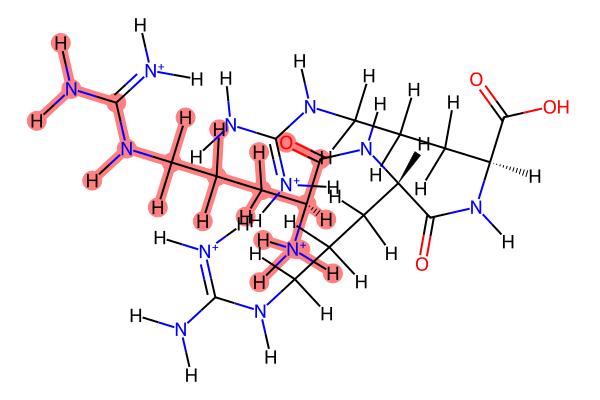

In [197]:
ref_aa['RRR']

In [25]:
# NR = mda.Universe('moleculse/aminoacids_template/NR.pdb')
NRCIT = mda.Universe('moleculse/substructure/TestNR_CIT_mod.pdb')
NRCIT.residues.resnums

/home/n_kristovsky/.conda/envs/topmol2/lib/python3.8/site-packages/psiresp/charge.py:282: FutureWarning: `symmetric_atoms_are_equivalent` will be set to False by default for now, as it is a new feature. It will be set to True by default in the future
  warnings.warn(


array([2])

In [184]:
for ref_indx, mod_indx in dict_mol1_mol2_matches.items():
    print( NR.atoms.names[ref_indx] + ':' + NRCIT.atoms.names[mod_indx])

N:N1
CA:C1
CB:C2
CG:C3
CD:C4
NE:N2
CZ:C5
NH1:N3
HH11:H1
HH12:H2
HE:H3
HD2:H4
HD3:H5
HG2:H6
HG3:H7
HB2:H8
HB3:H9
C:C6
O:O2
HA:H10
H1:H11
H2:H12
H3:H13


/home/n_kristovsky/.conda/envs/topmol2/lib//python3.8/site-packages/MDAnalysis/coordinates/PDB.py:432: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to None.
  warnings.warn("1 A^3 CRYST1 record,"


In [193]:
for ref_indx, mod_indx in dict_mol1_mol2_matches.items():
    NRCIT.atoms[mod_indx].name = NR.atoms[ref_indx].name 
print(NRCIT.atoms.names)

['N' 'CA' 'CB' 'CG' 'CD' 'NE' 'CZ' 'NH1' 'HH11' 'HH12' 'O1' 'HE' 'HD2'
 'HD3' 'HG2' 'HG3' 'HB2' 'HB3' 'C' 'O' 'HA' 'H1' 'H2' 'H3']


In [190]:
# NRCIT.atoms.names[1] = 'AD'
NRCIT.atoms.

'C1'

In [191]:
print(dict_mon_pol_matches)

{0: 0, 1: 1, 4: 2, 5: 3, 6: 4, 7: 5, 8: 6, 9: 7, 19: 8, 20: 9, 18: 11, 16: 12, 17: 13, 14: 14, 15: 15, 12: 16, 13: 17, 2: 18, 3: 19, 11: 20, 23: 21, 24: 22, 25: 23}


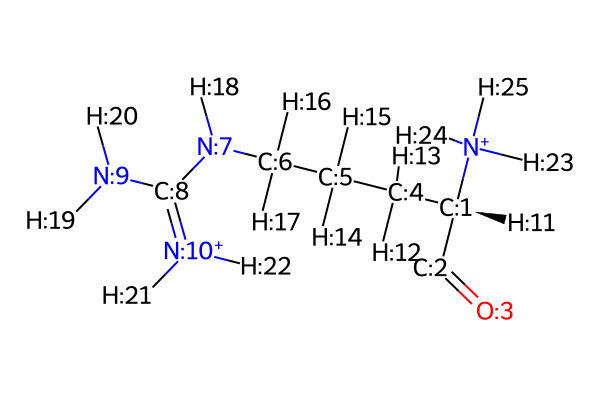

In [177]:
pt.draw_mol_with_atom_index(ref_aa['NR'])

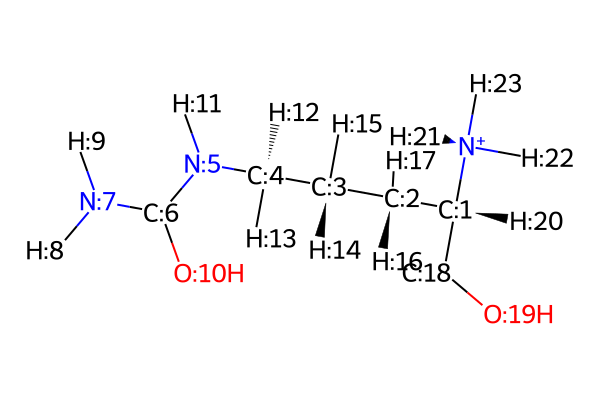

In [169]:
pt.draw_mol_with_atom_index(test_pdb_dict['TestNR_CIT_mod'])

In [151]:
mda_sub.residues.resids

array([1])

In [ ]:
list_N = []
for sub in match_dict['substructure'].values():
    N_index = pt.find_amino_nitrogen(sub)
    list_N.append(N_index)
print(list_N)
sub_name = ['NR_CIT', 'R_CIT', 'CR_CIT']
for chem_name, chem_mol, root in zip(sub_name, match_dict['substructure'].values(), list_N):
    pt.save_chem_to_pdb(chem_mol, f'moleculse/substructure/{chem_name}', rootedAtAtom = root)
    print(chem_name, chem_mol)

## Шаг 5. Расчет зарядов при помощи Espaloma charge

На вход: 
- Молекула-ы в виде тримеров в формате smiles. 

Задача ограничейни зарядов для одной молекулы
Словарь собранный для каждой молекулы полимера. Для каждого полимера он свой.
Задача ограничений зарядов для набора молекул
При растчете зарядов для нескольких молекул одновременно constraints теряются и не учитываются при расчетах. 
Так же теряется симетрия атомов. В связи с этим при использовании psiresp будут проводится расчеты для одной молекулы за раз. 



Создание ограничений

In [86]:
!pwd

/home/_shared/_projects/2022_md_FRET_nv/param_R_CIT


In [87]:
PTM_name

'Lysine_Cro'

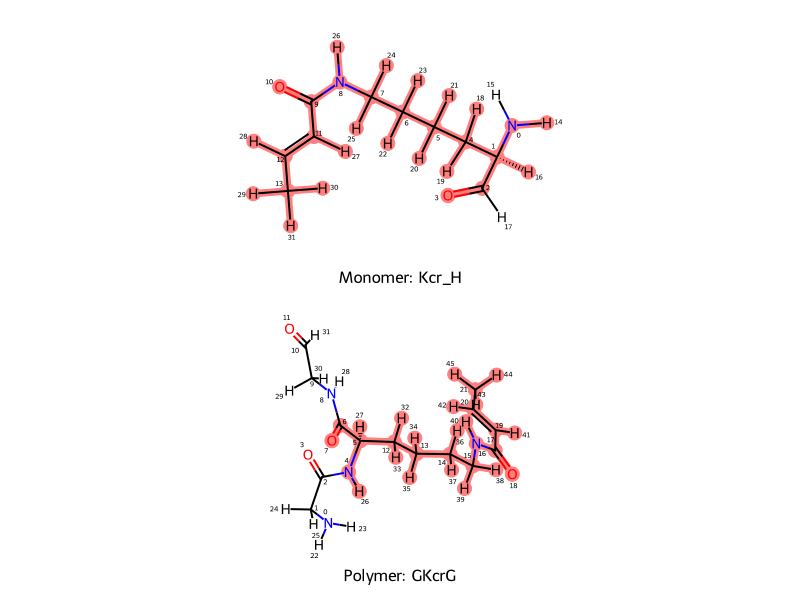

In [13]:
monomer_path = f'{PTM_name}/molecules/Kcr_H.smiles'
monomer_smi = pt.read_file(monomer_path)

trimer_path = f'{PTM_name}/molecules/GKcrG.smiles'
trimers_smi = pt.read_file([trimer_path, 
                            # 'moleculse/GRG_CIT.smiles',
                            # 'moleculse/GR_CIT.smiles',

                           ],)
monomer_chem = pt.smi_to_chem(monomer_smi, make_N_root=False) # RDKit читает smi строку, переводит в chem и добавляет протоны
trimers_chem = pt.smi_to_chem(trimers_smi, format_coord='3D')
trimers_chem

match_dict = pt.match_mon_to_pol(monomer_chem, trimers_chem, monomer_key = False)
pt.draw_mon_pol_match(monomer_chem, trimers_chem, match_dict, add_small_atom_index=True, img_size=(800,300))

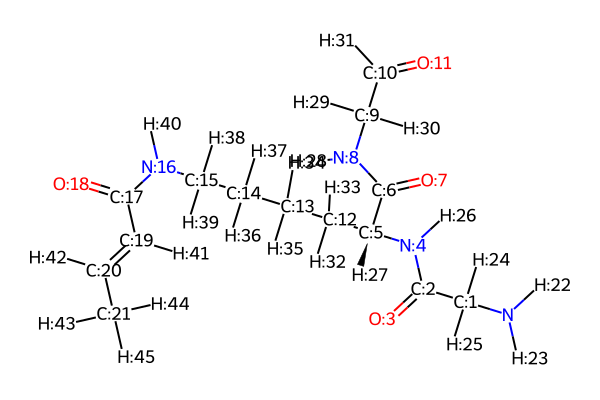

In [14]:
pt.draw_mol_with_atom_index(trimers_chem['GKcrG'])

In [15]:
trimer_charge = charge(trimers_chem['GKcrG'])
trimer_charge

/home/n_kristovsky/.conda/envs/ai_topmol/lib/python3.9/site-packages/dgl/heterograph.py:92: DGLWarning: Recommend creating graphs by `dgl.graph(data)` instead of `dgl.DGLGraph(data)`.
  dgl_warning(


array([-0.9509201 , -0.03813604,  0.7208049 , -0.71888083, -0.48852342,
        0.00111359,  0.6869182 , -0.738866  , -0.46459898, -0.16151893,
        0.6649663 , -0.57080644, -0.13501069, -0.13569702, -0.14587227,
        0.04513393, -0.5321461 ,  0.624817  , -0.6633657 , -0.22894442,
       -0.06983321, -0.13797744,  0.39434648,  0.39434648,  0.09860119,
        0.09860119,  0.3240243 ,  0.10347807,  0.324801  ,  0.10049627,
        0.10049627,  0.02581812,  0.09528708,  0.09528708,  0.09038935,
        0.09038935,  0.09256682,  0.09256682,  0.05925784,  0.05925784,
        0.32867533,  0.1654025 ,  0.13370071,  0.05651781,  0.05651782,
        0.05651782], dtype=float32)

In [18]:
pt.calculate_true_sum(trimer_charge)

Decimal('-1.243315637343E-7')

In [21]:
param_mol_name = 'GKcrG'
monomer_charge_list = pt.make_substructure_charge_list(param_mol_name, trimer_charge, match_dict )
print(pt.calculate_true_sum(monomer_charge_list), monomer_charge_list ,sep='\n')

-0.0182999633252619685
[-0.4885  0.0011  0.6869 -0.7389 -0.135  -0.1357 -0.1459  0.0451 -0.5321
  0.6248 -0.6634 -0.2289 -0.0698 -0.138   0.0565  0.0565  0.0565  0.1337
  0.1654  0.3287  0.0593  0.0593  0.0926  0.0926  0.0904  0.0904  0.0953
  0.0953  0.1035  0.324 ]


In [23]:
IPythonConsole.drawOptions.addAtomIndices = False
IPythonConsole.ipython_useSVG = True
IPythonConsole.molSize = (1200, 600)

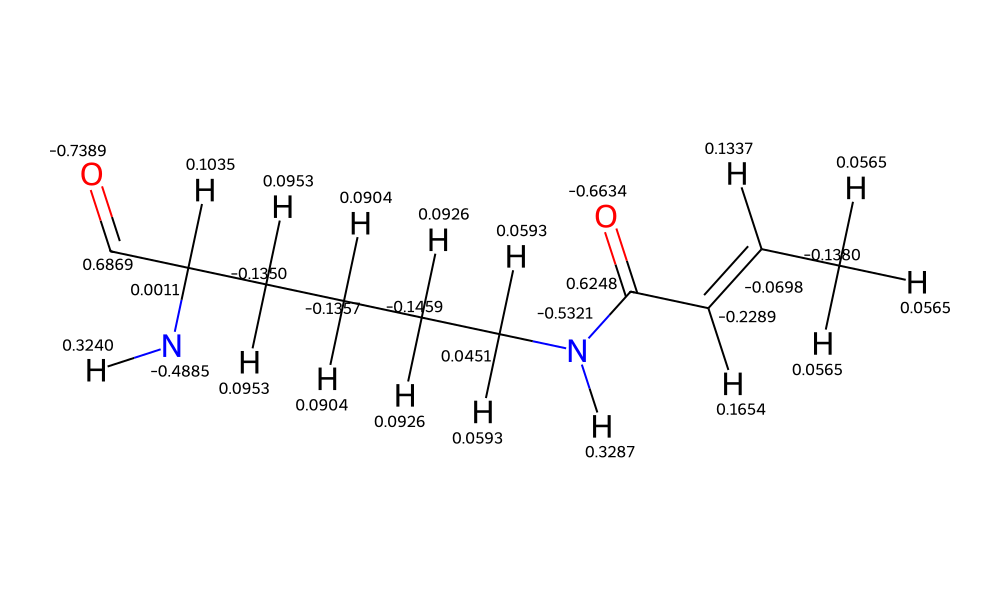

In [30]:
pt.draw_mol_with_atom_index(match_dict['substructure'][param_mol_name], 
                            charge_list = monomer_charge_list, 
                            size=(1000,600))

## Сохранение масcива зарядов

In [99]:
import json
import os

def save_charges_json(name: str, charge_list: list, path: str = ".") -> None:
    """
    Сохраняет список зарядов в JSON-файл с указанием абсолютного пути
    
    Параметры:
    name (str): Название файла (без расширения)
    charge_list (list): Список зарядов для сохранения
    path (str): Путь для сохранения (по умолчанию текущая директория)
    """
    # Создаем директорию, если она не существует
    os.makedirs(path, exist_ok=True)
    
    # Формируем полный путь к файлу
    file_path = os.path.join(path, f"{name}.json")
    absolute_path = os.path.abspath(file_path)
    
    # Сохраняем данные
    with open(file_path, 'w') as convert_file:
        json.dump(charge_list, convert_file, indent=4)
    
    # Выводим информативное сообщение
    print(f"Файл успешно сохранен: \n{absolute_path}")

In [225]:
monomer_charge_list

array([-0.3479, -0.24  ,  0.7341, -0.5894, -0.1428,  0.0116,  0.0452,
        0.0174, -0.6059,  0.7574, -0.5597, -0.5335,  0.0618, -0.09  ,
        0.0452,  0.0452,  0.0452,  0.1004,  0.2221,  0.3068,  0.0633,
        0.0633,  0.0213,  0.0213,  0.0165,  0.0165,  0.0726,  0.0726,
        0.1426,  0.2747])

Выполнение run_optimization.sh.  

In [224]:
save_charges_json(name = name, charge_list = list(monomer_charge_list),  path = f'{dir_path}')

Файл успешно сохранен: 
/home/_shared/_projects/2022_md_FRET_nv/param_R_CIT/Lysine_Cro/GKcrG_03/GKcrG.smiles.json
Выполнение run_optimization.sh...

### Удаление папки

In [16]:
path = dir_path

'Lysine_Cro'

In [17]:
dir_path

'Lysine_Cro/GKcrG_20'

In [21]:
import shutil

In [31]:
for i in range(4,11):
    print(i)
    shutil.rmtree('Lysine_Cro/GKcrG_{}')

4
5
6
7
8
9
10


### Модификация заряда 

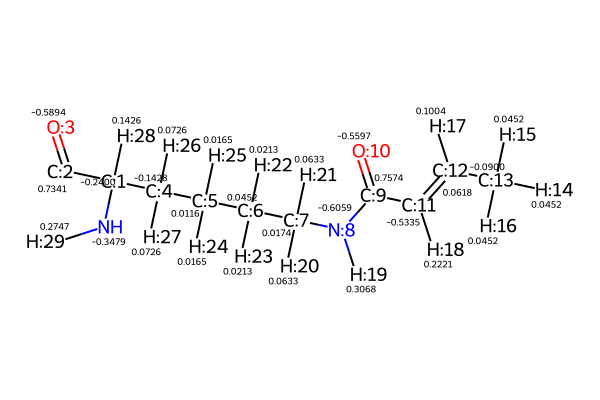

In [22]:
sub_smi = pt.read_file(f'Lysine_Cro/molecules/substructure/Kcr_H.smiles')
sub_chem = pt.smi_to_chem(sub_smi, addH=False, sanitize=False)


charges = [
    -0.3479, -0.24,    0.7341, -0.5894, -0.1428,  0.0116,
     0.0452,  0.0174, -0.6059,  0.7574, -0.5597, -0.5335,
     0.0618, -0.0900,  0.0452,  0.0452,  0.0452,  0.1004,
     0.2221,  0.3068,  0.0633,  0.0633,  0.0213,  0.0213,
     0.0165,  0.0165,  0.0726,  0.0726,  0.1426,  0.2747
]
pt.draw_mol_with_atom_index(sub_chem['Kcr_H'], charges)

In [23]:
pt.calculate_true_sum(charges)

Decimal('0.0479')

In [24]:
charges[7] -= 0.0479

In [25]:
charges[7]

-0.0305

In [26]:
pt.calculate_true_sum(charges)

Decimal('0.0000')

In [28]:
name

NameError: name 'name' is not defined

In [30]:
save_charges_json(name = 'GKcrG_0', charge_list =charges,  path = f'Lysine_Cro/GKcrG_03')

Файл успешно сохранен: 
/home/_shared/_projects/2022_md_FRET_nv/param_R_CIT/Lysine_Cro/GKcrG_03/GKcrG_0.json


NameError: name 'dir_path' is not defined

In [3]:
PTM_name

'Lysine_Cro'

In [22]:
np.save(f'Charge_list/{param_mol_name}_done.npy', monomer_charge_list)


GR_CIT


In [17]:
np.load(f'Charge_list/{param_mol_name}_done.npy')

array([-1.2866,  1.0232, -0.5923, -0.5637, -0.0571,  0.045 , -0.3981,
       -0.3068,  0.8557, -0.8266, -0.8266, -0.3479,  0.2764,  0.1447,
        0.1569,  0.1569,  0.0835,  0.0835,  0.0693,  0.0693,  0.2609,
        0.4902,  0.4902])

In [151]:
from rdkit import Chem
from rdkit.Chem import rdFMCS

def match_chem(mol_chem_1, mol_chem_2, compare_any_bond=False):
    """
    Принимает на вход две молекулы (RDKit.Chem.Mol) и находит их максимальную общую подструктуру (MCS),
    учитывая валентности атомов. Возвращает общую подструктуру и словарь соответствия атомов.
    """
    # Класс для сравнения атомов по элементам и валентности
    class CompareElements(rdFMCS.MCSAtomCompare):

        def __call__(self, p, mol1, atom1, mol2, atom2):
            a1 = mol1.GetAtomWithIdx(atom1)
            a2 = mol2.GetAtomWithIdx(atom2)
            if (a1.GetAtomicNum() != a2.GetAtomicNum()):
                return False
            if (p.MatchValences and a1.GetTotalValence() != a2.GetTotalValence()):
                print("Mismatch in formal charges:", a1.GetProp('AtomName'), a2.GetProp('AtomName'))
                return False
            if (p.MatchChiralTag and not self.CheckAtomChirality(p, mol1, atom1, mol2, atom2)):
                return False
            if a1.GetFormalCharge() != a2.GetFormalCharge():
                
                return False
            if p.RingMatchesRingOnly:
                return self.CheckAtomRingMatch(p, mol1, atom1, mol2, atom2)
            return True

    # Настройка сравнения связей
    bond_compare = rdFMCS.BondCompare.CompareAny if compare_any_bond else rdFMCS.BondCompare.CompareOrder

    # Создаем экземпляр компаратора
    # atom_compare = ElementValenceComparator()

    # Создаем объект параметров для MCS
    params = rdFMCS.MCSParameters()
    params.AtomCompareParameters.MatchValences = True
    # params.AtomCompareParameters.MatchChiralTag = True
    params.AtomCompareParameters.MatchFormalCharge = True
    params.AtomTyper = CompareElements()
    params.bondCompare = bond_compare
    # При необходимости можно настроить и другие параметры, например:
    
    # params.ringMatchesRingOnly = True
    # params.completeRingsOnly = True

    # Передаем список молекул и объект параметров
    res = rdFMCS.FindMCS([mol_chem_1, mol_chem_2], params)

    # Преобразование результата в молекулу
    mcs_smarts = res.smartsString
    substructure = Chem.MolFromSmarts(mcs_smarts)

    # Получение соответствий атомов
    matches_mol1 = mol_chem_1.GetSubstructMatch(substructure)
    matches_mol2 = mol_chem_2.GetSubstructMatch(substructure)
    dict_matches = dict(zip(matches_mol1, matches_mol2))

    # Копирование зарядов из второй молекулы в подструктуру
    # for atom in mol_chem_2.GetAtoms():
    #     if atom.GetFormalCharge() != 0 and atom.GetIdx() in matches_mol2:
    #         substruct_idx = matches_mol2.index(atom.GetIdx())
    #         substructure.GetAtomWithIdx(substruct_idx).SetFormalCharge(atom.GetFormalCharge())

    return substructure, dict_matches


In [155]:
smile1 = pt.read_file('moleculse/Lysine_1M_ACC.smiles')
mol1 = pt.smi_to_chem(smile1)
mol1 = pt.rdkit_pdb_modification(mol1['Lysine_1M_ACC'])
mol2 = pt.pdb_to_chem('moleculse/aminoacids_template/AKA.pdb')

Длина atom_names_list не совпадает с количеством атомов в rdkit_mol. Будут использованы стандартные имена атомов.


In [157]:
substructure, dict_matches = match_chem(mol1, mol2['AKA'],  compare_any_bond=True)

Mismatch in formal charges: N1 N
Mismatch in formal charges: N2 N
Mismatch in formal charges: N1 NZ
Mismatch in formal charges: N2 NZ


In [158]:
for atom in mol2['KK'].GetAtoms():
    print(atom.GetProp('AtomName'), atom.GetTotalValence())

KeyError: 'KK'

In [159]:
for atom in mol1.GetAtoms():
    print(atom.GetProp('AtomName'), atom.GetTotalValence())

N1 3
C1 4
C2 4
O1 2
C3 4
C4 4
C5 4
C6 4
N2 3
C7 4
O2 2
C8 4
C9 4
H1 1
H2 1
H3 1
H4 1
H5 1
H6 1
H7 1
H8 1
H9 1
H10 1
H11 1
H12 1
H13 1
H14 1
H15 1
H16 1
H17 1
H18 1


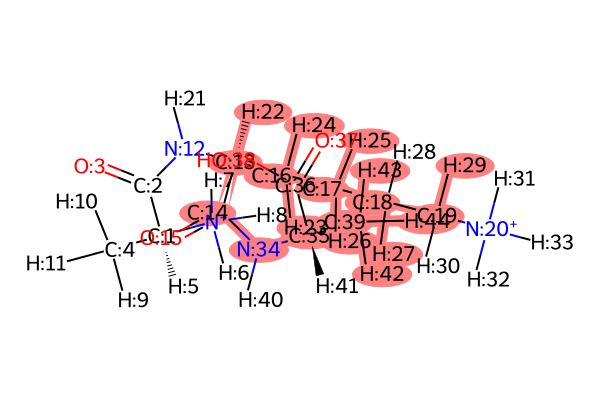

In [160]:
mol2['AKA']

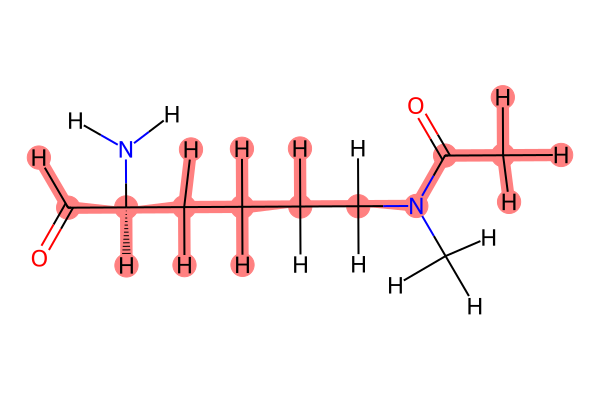

In [161]:
mol1

In [348]:
print(mol1, mol2['K'])

<rdkit.Chem.rdchem.Mol object at 0x7f73f3527c80> <rdkit.Chem.rdchem.Mol object at 0x7f73f35d0dd0>


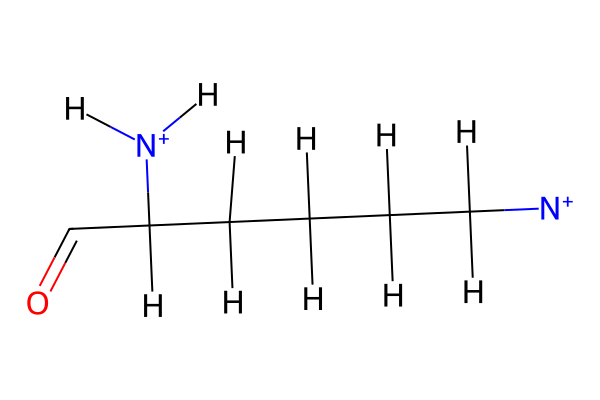

In [371]:
substructure

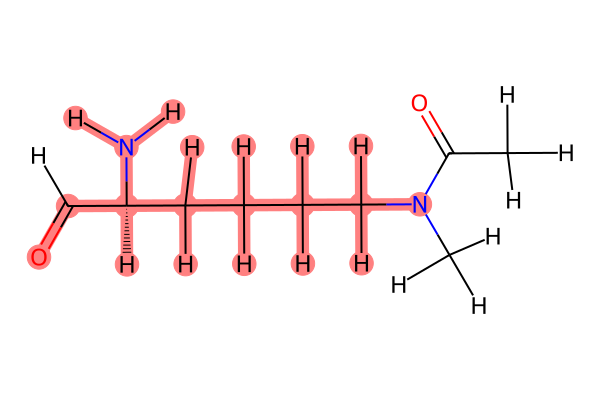

In [355]:
mol1

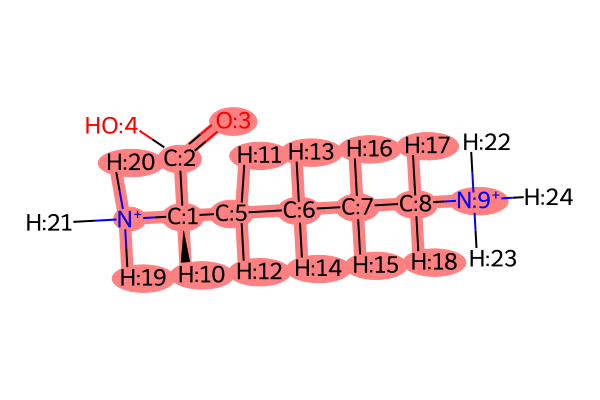

In [356]:
mol2['K']

In [339]:
mol1_d = {}
mol2_d = {}
for atom in mol1.GetAtoms():
    mol1_d[atom.GetProp('AtomName')] = atom.GetTotalValence()
for atom in mol2['K'].GetAtoms():
    mol2_d[atom.GetProp('AtomName')] = atom.GetTotalValence()
    

In [342]:
print(mol1_d, mol2_d, sep='\n')

{'N1': 3, 'C1': 4, 'C2': 4, 'O1': 2, 'C3': 4, 'C4': 4, 'C5': 4, 'C6': 4, 'N2': 3, 'C7': 4, 'O2': 2, 'C8': 4, 'C9': 4, 'H1': 1, 'H2': 1, 'H3': 1, 'H4': 1, 'H5': 1, 'H6': 1, 'H7': 1, 'H8': 1, 'H9': 1, 'H10': 1, 'H11': 1, 'H12': 1, 'H13': 1, 'H14': 1, 'H15': 1, 'H16': 1, 'H17': 1, 'H18': 1}
{'N': 4, 'CA': 4, 'C': 4, 'O': 2, 'OXT': 2, 'CB': 4, 'CG': 4, 'CD': 4, 'CE': 4, 'NZ': 4, 'HA': 1, 'HB1': 1, 'HB2': 1, 'HG1': 1, 'HG2': 1, 'HD1': 1, 'HD2': 1, 'HE1': 1, 'HE2': 1, 'H1': 1, 'H2': 1, 'H3': 1, 'HZ1': 1, 'HZ2': 1, 'HZ3': 1}


In [47]:
!pwd

/home/_shared/_projects/2022_md_FRET_nv/param_R_CIT


In [106]:
%%bash
module load gromacs/2021.4_nompi

gmx pdb2gmx -f moleculse/aminoacids_template/cKc.pdb -o moleculse/aminoacids_template/cKc_H.pdb -p topol_cKc_H.top -i moleculse/aminoacids_template/topol_cKc_H.itp -water none -ff amber14sb_parmbsc1_cufix

/home/n_kristovsky/.conda/envs/topmol2/lib/python3.8/site-packages/psiresp/charge.py:282: FutureWarning: `symmetric_atoms_are_equivalent` will be set to False by default for now, as it is a new feature. It will be set to True by default in the future
  warnings.warn(
(Un)Loading module for modern CPU
                     :-) GROMACS - gmx pdb2gmx, 2021.4 (-:

                            GROMACS is written by:
     Andrey Alekseenko              Emile Apol              Rossen Apostolov     
         Paul Bauer           Herman J.C. Berendsen           Par Bjelkmar       
       Christian Blau           Viacheslav Bolnykh             Kevin Boyd        
     Aldert van Buuren           Rudi van Drunen             Anton Feenstra      
    Gilles Gouaillardet             Alan Gray               Gerrit Groenhof      
       Anca Hamuraru            Vincent Hindriksen          M. Eric Irrgang      
      Aleksei Iupinov           Christoph Junghans             Joe Jordan        
    Dimitrios

Using the Amber14sb_parmbsc1_cufix force field in directory ./amber14sb_parmbsc1_cufix.ff

going to rename ./amber14sb_parmbsc1_cufix.ff/aminoacids.r2b

going to rename ./amber14sb_parmbsc1_cufix.ff/dna.r2b

going to rename ./amber14sb_parmbsc1_cufix.ff/rna.r2b
Reading moleculse/aminoacids_template/cKc.pdb...
Read 'NULL', 16 atoms

Analyzing pdb file
Splitting chemical chains based on TER records or chain id changing.

There are 1 chains and 0 blocks of water and 4 residues with 16 atoms

  chain  #res #atoms

  1 ' '     4     16  

All occupancy fields zero. This is probably not an X-Ray structure

Reading residue database... (Amber14sb_parmbsc1_cufix)

Processing chain 1 (16 atoms, 4 residues)

Identified residue ALA1 as a starting terminus.

Identified residue ALA3 as a ending terminus.


CalledProcessError: Command 'b'module load gromacs/2021.4_nompi\n\ngmx pdb2gmx -f moleculse/aminoacids_template/cKc.pdb -o moleculse/aminoacids_template/cKc_H.pdb -p topol_cKc_H.top -i moleculse/aminoacids_template/topol_cKc_H.itp -water none -ff amber14sb_parmbsc1_cufix\n'' returned non-zero exit status 1.

In [ ]:
Chem.MolFromPDBFile()

/home/n_kristovsky/.conda/envs/topmol2/lib/python3.8/site-packages/psiresp/charge.py:282: FutureWarning: `symmetric_atoms_are_equivalent` will be set to False by default for now, as it is a new feature. It will be set to True by default in the future
  warnings.warn(


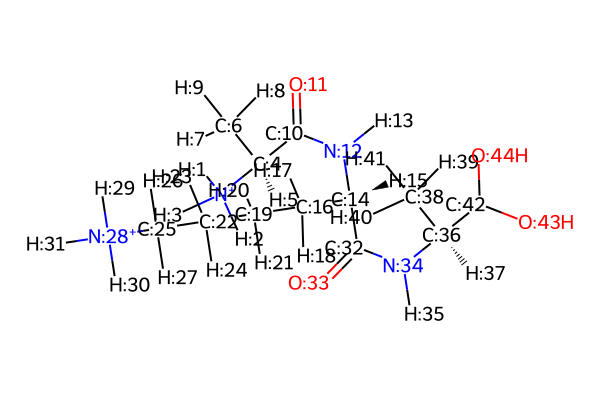

In [95]:
# smi = pt.read_file('moleculse/GRG_CIT.smiles')
# chem = pt.smi_to_chem(smi)
chem = pt.pdb_to_chem('moleculse/aminoacids_template/AKA_H.pdb')
pt.draw_mol_with_atom_index(chem['AKA_H'])

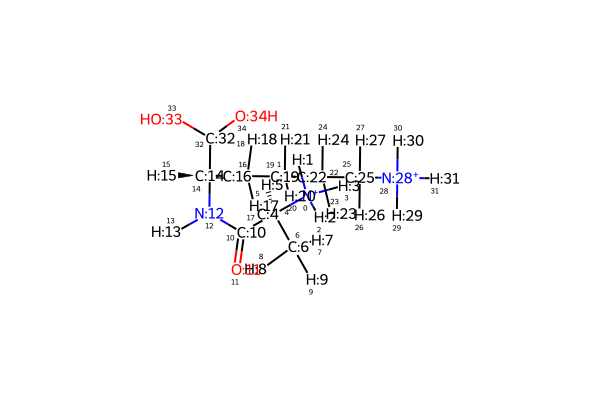

In [79]:
draw_mol_with_atom_index(mol=ref_aa_chem_dict['AK_rn'])

In [102]:
# mol=ref_aa_chem_dict['AK_rn']
AllChem.Compute2DCoords(chem['AKA_H'] )

0

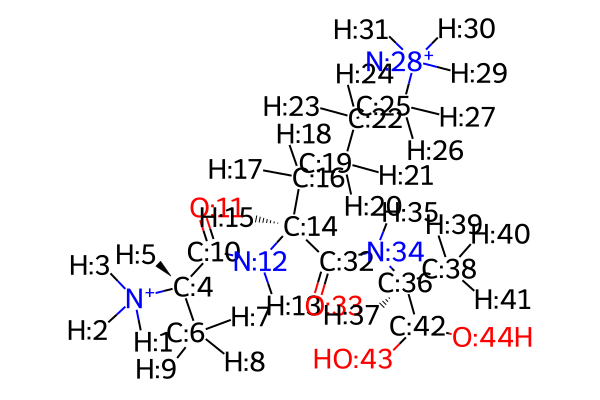

In [105]:
from rdkit.Chem import rdCoordGen
rdCoordGen.AddCoords(chem['AKA_H'])
chem['AKA_H']

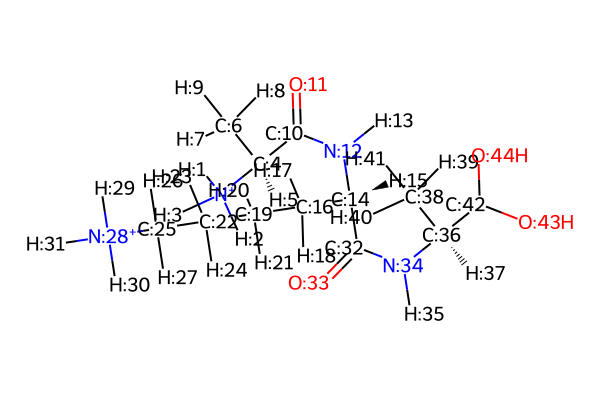

In [103]:
chem['AKA_H']